# Train, Evaluate & Export the Baseline LSTM

We train the `mindwave_stress_lstm` model on the cached WESAD wrist windows and:
1. report a **fast subject-wise hold-out** (S13 + S16) with rich plots,
2. run **Leave-One-Subject-Out** cross-validation for a trustworthy headline number,
3. fit a **final model on all subjects** and convert it to **TFLite** (float + int8) for the Android app

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from src.config import LABEL_NAMES, MODELS_DIR, PROCESSED_DIR, set_global_seed
from src.train import (
    load_npz, run_holdout, run_loso, train_final_and_export,
)
from src.evaluate import (
    metrics_dict, plot_confusion_matrix, plot_training_curves, plot_roc_pr,
    compare_keras_vs_tflite,
)
from src.tflite_export import run_tflite

sns.set_theme(style='whitegrid')
set_global_seed()
print('TF:', tf.__version__)

TF: 2.21.0


## Load the cached dataset

X: (1738, 12, 23) y: (1738,) | subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


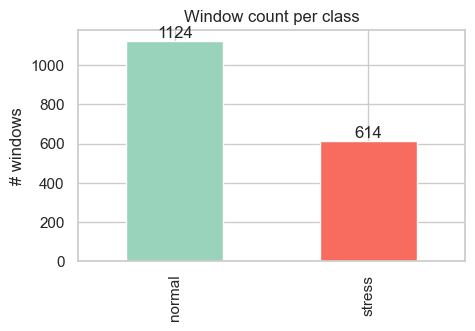

In [2]:
X, y, subject_ids, feature_names = load_npz(PROCESSED_DIR / 'wesad_wrist.npz')
print('X:', X.shape, 'y:', y.shape, '| subjects:', np.unique(subject_ids).tolist())

vc = pd.Series(y).map(LABEL_NAMES).value_counts()
fig, ax = plt.subplots(figsize=(5, 3))
vc.plot(kind='bar', color=['#9ad3bc', '#f76c5e', '#ffd166'], ax=ax)
ax.set_title('Window count per class'); ax.set_ylabel('# windows')
for c in ax.containers: ax.bar_label(c)

## Fast hold-out fold (subjects S13 + S16)

In [3]:
model, scaler, history, metrics, y_score = run_holdout(
    X, y, subject_ids, holdout=('S13', 'S16'),
    n_classes=2, epochs=60, batch_size=64,
)
print(json.dumps(metrics, indent=2))

# Persist hold-out metrics
(MODELS_DIR / 'holdout_metrics.json').write_text(json.dumps(metrics, indent=2))
print('Saved holdout_metrics.json')

Hold-out subjects: ['S13', 'S16'] | train windows=1505 test windows=233
Epoch 1/60
48/48 - 7s - 139ms/step - accuracy: 0.8561 - loss: 0.3817 - val_accuracy: 0.9871 - val_loss: 0.1011 - learning_rate: 0.0010
Epoch 2/60
48/48 - 1s - 13ms/step - accuracy: 0.9754 - loss: 0.1002 - val_accuracy: 0.9785 - val_loss: 0.0787 - learning_rate: 0.0010
Epoch 3/60
48/48 - 1s - 12ms/step - accuracy: 0.9857 - loss: 0.0682 - val_accuracy: 0.9871 - val_loss: 0.0708 - learning_rate: 0.0010
Epoch 4/60
48/48 - 1s - 11ms/step - accuracy: 0.9900 - loss: 0.0518 - val_accuracy: 0.9785 - val_loss: 0.0862 - learning_rate: 0.0010
Epoch 5/60
48/48 - 0s - 10ms/step - accuracy: 0.9957 - loss: 0.0377 - val_accuracy: 0.9700 - val_loss: 0.1216 - learning_rate: 0.0010
Epoch 6/60
48/48 - 1s - 11ms/step - accuracy: 0.9970 - loss: 0.0321 - val_accuracy: 0.9871 - val_loss: 0.0938 - learning_rate: 0.0010
Epoch 7/60
48/48 - 1s - 11ms/step - accuracy: 0.9980 - loss: 0.0295 - val_accuracy: 0.9657 - val_loss: 0.1585 - learning_ra

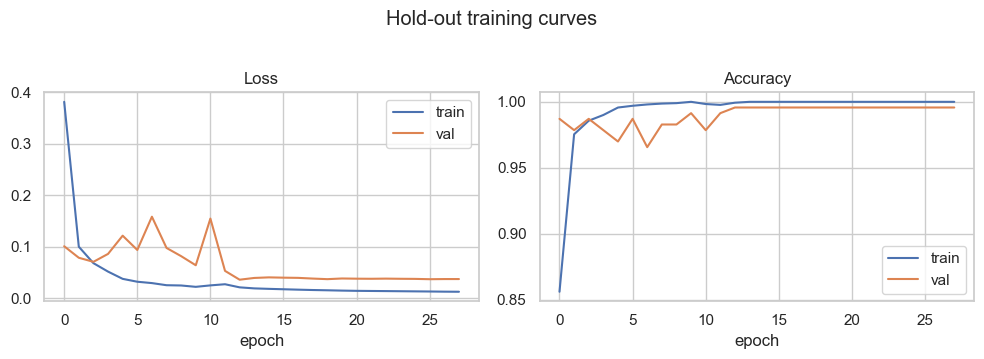

In [4]:
plot_training_curves(history)
plt.suptitle('Hold-out training curves', y=1.02); plt.tight_layout()

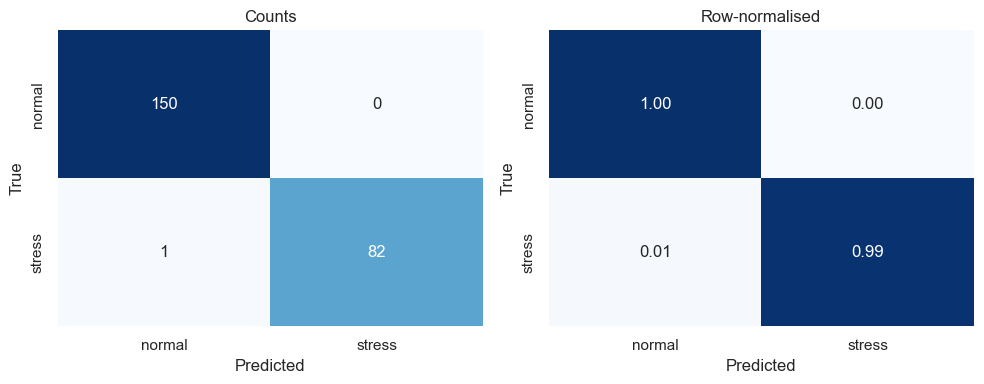

In [5]:
y_pred = y_score.argmax(1)
test_mask = np.isin(subject_ids, ['S13', 'S16'])
y_test = y[test_mask]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_matrix(y_test, y_pred, normalize=False, ax=axes[0], title='Counts')
plot_confusion_matrix(y_test, y_pred, normalize=True,  ax=axes[1], title='Row-normalised')
fig.tight_layout()

(array([0, 1]), [Text(0, 0, 'normal'), Text(1, 0, 'stress')])

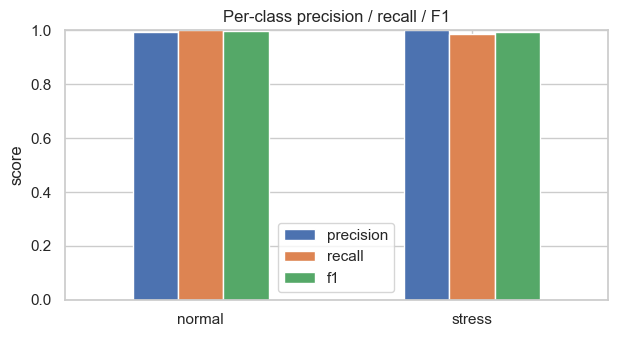

In [6]:
per_cls = pd.DataFrame(metrics['per_class']).T
ax = per_cls[['precision', 'recall', 'f1']].plot.bar(figsize=(7, 3.5))
ax.set_ylim(0, 1); ax.set_title('Per-class precision / recall / F1')
ax.set_ylabel('score'); plt.xticks(rotation=0)

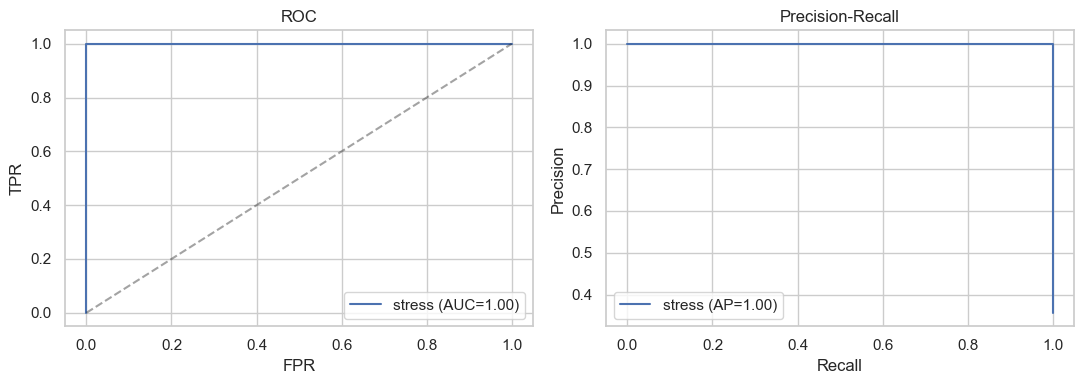

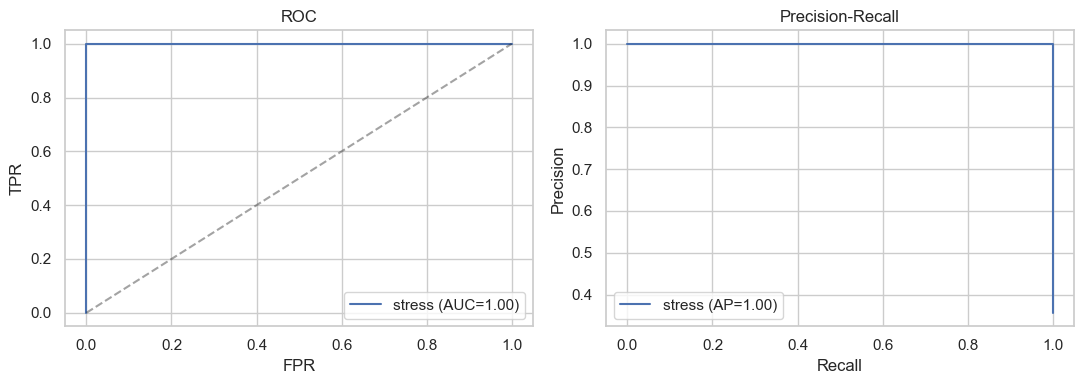

In [7]:
plot_roc_pr(y_test, y_score)

## Leave-One-Subject-Out cross-validation


=== LOSO fold: held-out subject = S10 (train=1617, test=121) ===
   accuracy=0.917  macro_f1=0.915

=== LOSO fold: held-out subject = S11 (train=1621, test=117) ===
   accuracy=1.000  macro_f1=1.000

=== LOSO fold: held-out subject = S13 (train=1621, test=117) ===
   accuracy=1.000  macro_f1=1.000

=== LOSO fold: held-out subject = S14 (train=1621, test=117) ===
   accuracy=0.923  macro_f1=0.918

=== LOSO fold: held-out subject = S15 (train=1620, test=118) ===
   accuracy=0.839  macro_f1=0.829

=== LOSO fold: held-out subject = S16 (train=1622, test=116) ===
   accuracy=1.000  macro_f1=1.000

=== LOSO fold: held-out subject = S17 (train=1617, test=121) ===
   accuracy=0.950  macro_f1=0.945

=== LOSO fold: held-out subject = S2 (train=1628, test=110) ===
   accuracy=0.964  macro_f1=0.958

=== LOSO fold: held-out subject = S3 (train=1627, test=111) ===
   accuracy=0.937  macro_f1=0.931

=== LOSO fold: held-out subject = S4 (train=1625, test=113) ===
   accuracy=1.000  macro_f1=1.000

==

,accuracy,macro_f1
S10,0.917,0.915
S11,1.000,1.000
S13,1.000,1.000
S14,0.923,0.918
S15,0.839,0.829
S16,1.000,1.000
S17,0.950,0.945
S2,0.964,0.958
S3,0.937,0.931
S4,1.000,1.000


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, 'S10'),
  Text(1, 0, 'S11'),
  Text(2, 0, 'S13'),
  Text(3, 0, 'S14'),
  Text(4, 0, 'S15'),
  Text(5, 0, 'S16'),
  Text(6, 0, 'S17'),
  Text(7, 0, 'S2'),
  Text(8, 0, 'S3'),
  Text(9, 0, 'S4'),
  Text(10, 0, 'S5'),
  Text(11, 0, 'S6'),
  Text(12, 0, 'S7'),
  Text(13, 0, 'S8'),
  Text(14, 0, 'S9')])

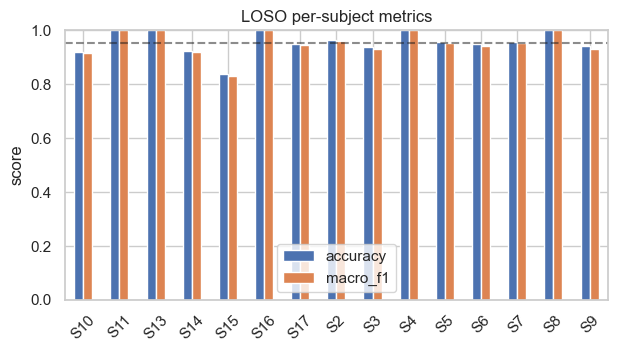

In [8]:
loso_summary = run_loso(X, y, subject_ids, n_classes=2, epochs=40, batch_size=64)
print(json.dumps({k: v for k, v in loso_summary.items() if k != 'per_fold'}, indent=2))

# Persist LOSO metrics
(MODELS_DIR / 'loso_metrics.json').write_text(json.dumps(loso_summary, indent=2))
print('Saved loso_metrics.json')

fold_df = pd.DataFrame({
    sid: {'accuracy': m['accuracy'], 'macro_f1': m['macro_f1']}
    for sid, m in loso_summary['per_fold'].items()
}).T.sort_index()
display(fold_df.round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
fold_df.plot(kind='bar', ax=ax)
ax.set_ylim(0, 1); ax.axhline(loso_summary['mean_macro_f1'], ls='--', color='k', alpha=0.5)
ax.set_title('LOSO per-subject metrics'); ax.set_ylabel('score'); plt.xticks(rotation=45)

## 4. Train final model on all subjects + export to TFLite

In [9]:
export_info = train_final_and_export(
    X, y, n_classes=2, epochs=40, batch_size=64,
    label_names=LABEL_NAMES, feature_names=feature_names,
)
export_info


 Training final model on all subjects
Epoch 1/40
28/28 - 6s - 212ms/step - accuracy: 0.7146 - loss: 0.5452
Epoch 2/40
28/28 - 0s - 15ms/step - accuracy: 0.9603 - loss: 0.2095
Epoch 3/40
28/28 - 0s - 16ms/step - accuracy: 0.9770 - loss: 0.1099
Epoch 4/40
28/28 - 0s - 18ms/step - accuracy: 0.9850 - loss: 0.0763
Epoch 5/40
28/28 - 0s - 14ms/step - accuracy: 0.9931 - loss: 0.0669
Epoch 6/40
28/28 - 0s - 13ms/step - accuracy: 0.9937 - loss: 0.0518
Epoch 7/40
28/28 - 0s - 14ms/step - accuracy: 0.9954 - loss: 0.0439
Epoch 8/40
28/28 - 0s - 16ms/step - accuracy: 0.9960 - loss: 0.0395
Epoch 9/40
28/28 - 0s - 17ms/step - accuracy: 0.9971 - loss: 0.0405
Epoch 10/40
28/28 - 0s - 16ms/step - accuracy: 0.9960 - loss: 0.0368
Epoch 11/40
28/28 - 0s - 13ms/step - accuracy: 0.9977 - loss: 0.0329
Epoch 12/40
28/28 - 0s - 12ms/step - accuracy: 0.9977 - loss: 0.0295
Epoch 13/40
28/28 - 0s - 12ms/step - accuracy: 0.9988 - loss: 0.0261
Epoch 14/40
28/28 - 0s - 12ms/step - accuracy: 1.0000 - loss: 0.0247
Epo

INFO:tensorflow:Assets written to: C:\Users\daniion6\AppData\Local\Temp\tmpn6uyxeza\assets


Saved artifact at 'C:\Users\daniion6\AppData\Local\Temp\tmpn6uyxeza'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 23), dtype=tf.float32, name='features')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1698024273296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1697986113424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315297424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315297808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315302224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315295312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315301648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315299536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315300880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315298000: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorfl

INFO:tensorflow:Assets written to: C:\Users\daniion6\AppData\Local\Temp\tmpdf6m0ta5\assets


Saved artifact at 'C:\Users\daniion6\AppData\Local\Temp\tmpdf6m0ta5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 23), dtype=tf.float32, name='features')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1698024273296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1697986113424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315297424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315297808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315302224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315295312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315301648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315299536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315300880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1699315298000: TensorSpec(shape=(), dtype=tf.resource, name=None)

Export summa

c:\Users\daniion6\AndroidStudioProjects\MindWave\.venv-312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


{'keras': 'C:\\Users\\daniion6\\AndroidStudioProjects\\MindWave\\ml\\models\\mindwave_stress.keras',
 'tflite_float': 'C:\\Users\\daniion6\\AndroidStudioProjects\\MindWave\\ml\\models\\mindwave_stress.tflite',
 'tflite_int8': 'C:\\Users\\daniion6\\AndroidStudioProjects\\MindWave\\ml\\models\\mindwave_stress_int8.tflite',
 'parity': {'max_abs_diff': 1.0477378964424133e-09,
  'mean_abs_diff': 9.386269539390923e-12,
  'argmax_agreement': 1.0,
  'tflite_float_kb': 232.7,
  'tflite_int8_kb': 138.2}}

## Keras vs TFLite numerical parity

c:\Users\daniion6\AndroidStudioProjects\MindWave\.venv-312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


float TFLite parity : {'max_abs_diff': 1.0477378964424133e-09, 'mean_abs_diff': 1.3040679647247089e-11, 'argmax_agreement': 1.0}
int8  TFLite parity : {'max_abs_diff': 3.078754525631666e-05, 'mean_abs_diff': 4.667381290346384e-07, 'argmax_agreement': 1.0}


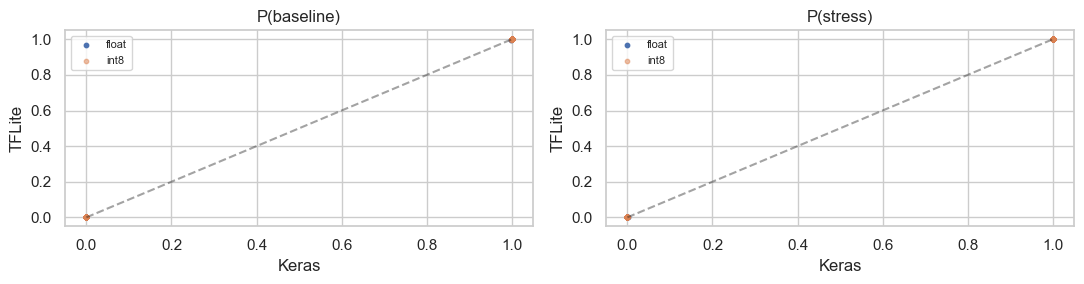

In [11]:
from tensorflow.keras.models import load_model
model = load_model(MODELS_DIR / 'mindwave_stress.keras')
sample = X[:128].astype(np.float32)
# Apply the same scaler used in train_final_and_export.
import joblib
scaler = joblib.load(MODELS_DIR / 'scaler.pkl')
n, t, f = sample.shape
sample_s = scaler.transform(sample.reshape(-1, f)).reshape(n, t, f).astype(np.float32)

keras_pred = model.predict(sample_s, verbose=0)
tfl_pred = run_tflite(MODELS_DIR / 'mindwave_stress.tflite', sample_s)
tfl_int8_pred = run_tflite(MODELS_DIR / 'mindwave_stress_int8.tflite', sample_s)
print('float TFLite parity :', compare_keras_vs_tflite(keras_pred, tfl_pred))
print('int8  TFLite parity :', compare_keras_vs_tflite(keras_pred, tfl_int8_pred))

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for i, name in enumerate(['baseline', 'stress']):
    axes[i].scatter(keras_pred[:, i], tfl_pred[:, i], s=10, label='float')
    axes[i].scatter(keras_pred[:, i], tfl_int8_pred[:, i], s=10, alpha=0.5, label='int8')
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.4)
    axes[i].set_title(f'P({name})'); axes[i].set_xlabel('Keras'); axes[i].set_ylabel('TFLite')
    axes[i].legend(fontsize=8)
fig.tight_layout()

Artifacts saved under `ml/models/`:
* `mindwave_stress.keras` — full Keras model
* `mindwave_stress.tflite` — float32 TFLite (mobile)
* `mindwave_stress_int8.tflite` — int8 TFLite (smartwatch)
* `scaler.pkl`, `label_map.json`, `feature_names.json`
* `loso_metrics.json`, `holdout_metrics.json`